## CELL 1 — Environment Verification

In [1]:
# CELL 1 — ENVIRONMENT VERIFICATION
import torch
import geopandas as gpd
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"GeoPandas   : {gpd.__version__}")
print(f"Rasterio    : {rasterio.__version__}")
print(f"NumPy       : {np.__version__}")
print("--- ALL SYSTEMS OPERATIONAL ---")

PyTorch     : 2.11.0+cu128
CUDA        : True
GPU         : NVIDIA GeForce RTX 5060 Laptop GPU
GeoPandas   : 1.1.3
Rasterio    : 1.4.4
NumPy       : 2.4.3
--- ALL SYSTEMS OPERATIONAL ---


## CELL 2 — Configuration & Weights

In [2]:
# CELL 2 — CONFIGURATION & APPROVED WEIGHT MATRIX

WEIGHTS = {
    "lulc":           0.30,
    "ghi":            0.25,
    "grid_distance":  0.20,
    "road_distance":  0.10,
    "slope":          0.10,
    "aspect":         0.05
}

total = sum(WEIGHTS.values())
assert round(total, 10) == 1.0, f"Weights must sum to 1.0 — got {total}"

print("Weight Matrix Approved:")
for k, v in WEIGHTS.items():
    print(f"  {k:<20} {v:.0%}")
print(f"\nTotal: {total}")

Weight Matrix Approved:
  lulc                 30%
  ghi                  25%
  grid_distance        20%
  road_distance        10%
  slope                10%
  aspect               5%

Total: 1.0


## CELL 3 — File Paths

In [3]:
# CELL 3 — FILE PATHS
import os

PATHS = {
    "aoi":           r"data\raw\AOI Shapefile.shp",
    "dem":           r"data\raw\dem_jodhpur.tif",
    "lulc":          r"data\raw\LULC Raster.tif",
    "ghi":           r"data\raw\GHI Raster.tif",
    "grid_dist":     r"data\raw\Grid Distance.tif",
    "road_dist":     r"data\raw\Road Distance.tif",
    "slope":         r"data\raw\slope.tif",
    "aspect":        r"data\raw\aspect.tif",
    "output_mcda":   r"data\output\agrivoltaic_suitability.tif",
    "output_cluster":r"data\output\cluster_output.tif",
    "elbow_chart":   r"data\output\elbow_chart.png"
}

# Create output folder if not exists
os.makedirs(r"data\output", exist_ok=True)
os.makedirs(r"data\processed", exist_ok=True)

print("File Path Status:")
for name, path in PATHS.items():
    status = "EXISTS" if os.path.exists(path) else "MISSING"
    print(f"  {name:<20} {status}  ({path})")

File Path Status:
  aoi                  EXISTS  (data\raw\AOI Shapefile.shp)
  dem                  EXISTS  (data\raw\dem_jodhpur.tif)
  lulc                 EXISTS  (data\raw\LULC Raster.tif)
  ghi                  EXISTS  (data\raw\GHI Raster.tif)
  grid_dist            EXISTS  (data\raw\Grid Distance.tif)
  road_dist            EXISTS  (data\raw\Road Distance.tif)
  slope                EXISTS  (data\raw\slope.tif)
  aspect               EXISTS  (data\raw\aspect.tif)
  output_mcda          MISSING  (data\output\agrivoltaic_suitability.tif)
  output_cluster       MISSING  (data\output\cluster_output.tif)
  elbow_chart          MISSING  (data\output\elbow_chart.png)


## CELL 4 — Raster Alignment Verification

In [4]:
# CELL 4 — RASTER ALIGNMENT VERIFICATION

print("=" * 55)
print("  RASTER ALIGNMENT VERIFICATION")
print("=" * 55)

rasters_to_check = {
    "DEM":           PATHS["dem"],
    "Slope":         PATHS["slope"],
    "Aspect":        PATHS["aspect"],
    "LULC":          PATHS["lulc"],
    "GHI":           PATHS["ghi"],
    "Grid Distance": PATHS["grid_dist"],
    "Road Distance": PATHS["road_dist"],
}

metadata = {}

for name, path in rasters_to_check.items():
    with rasterio.open(path) as src:
        metadata[name] = {
            "crs":        str(src.crs),
            "width":      src.width,
            "height":     src.height,
            "resolution": (round(src.res[0], 6), round(src.res[1], 6)),
            "bounds":     src.bounds,
            "dtype":      src.dtypes[0]
        }
    m = metadata[name]
    print(f"\n{name}")
    print(f"  CRS        : {m['crs'][:60]}")
    print(f"  Dimensions : {m['width']} x {m['height']}")
    print(f"  Resolution : {m['resolution']}")
    print(f"  Dtype      : {m['dtype']}")
    print(f"  Bounds     : {m['bounds']}")

# Alignment checks against DEM as reference
ref = metadata["DEM"]
print("\n" + "=" * 55)
print("  ALIGNMENT CHECKS vs DEM")
print("=" * 55)

all_passed = True
for name in list(rasters_to_check.keys())[1:]:
    m = metadata[name]
    crs_ok  = m["crs"] == ref["crs"]
    dim_ok  = (m["width"], m["height"]) == (ref["width"], ref["height"])
    res_ok  = m["resolution"] == ref["resolution"]
    bnd_ok  = (round(m["bounds"].left,4) == round(ref["bounds"].left,4) and
               round(m["bounds"].bottom,4) == round(ref["bounds"].bottom,4))

    results = {
        "CRS Match":        crs_ok,
        "Dimensions Match": dim_ok,
        "Resolution Match": res_ok,
        "Bounds Match":     bnd_ok
    }

    print(f"\n  {name}")
    for check, passed in results.items():
        icon = "PASS" if passed else "FAIL"
        print(f"    {check:<20} {icon}")
        if not passed:
            all_passed = False

print("\n" + "=" * 55)
if all_passed:
    print("  ALL CHECKS PASSED — Safe to run pipeline.")
else:
    print("  FAILURES DETECTED — Report to Orion.")
print("=" * 55)

  RASTER ALIGNMENT VERIFICATION

DEM
  CRS        : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID[
  Dimensions : 7495 x 6350
  Resolution : (0.000278, 0.000278)
  Dtype      : int16
  Bounds     : BoundingBox(left=71.78930555555556, bottom=25.851805555555558, right=73.87125, top=27.615694444444447)

Slope
  CRS        : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID[
  Dimensions : 7495 x 6350
  Resolution : (0.000278, 0.000278)
  Dtype      : float32
  Bounds     : BoundingBox(left=71.78930555555556, bottom=25.851805555555558, right=73.87125, top=27.615694444444447)

Aspect
  CRS        : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID[
  Dimensions : 7495 x 6350
  Resolution : (0.000278, 0.000278)
  Dtype      : float32
  Bounds     : BoundingBox(left=71.78930555555556, bottom=25.851805555555558, right=73.87125, top=27.615694444444447)

LULC
  CRS        : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID[
  Dimensions : 23176 x 19633

In [5]:
# CELL 5 — QUICK ALIGNMENT SUMMARY

import rasterio

ref_name = "DEM"
ref_path = PATHS["dem"]

with rasterio.open(ref_path) as src:
    ref_crs  = str(src.crs)
    ref_dim  = (src.width, src.height)
    ref_res  = (round(src.res[0], 6), round(src.res[1], 6))
    ref_left = round(src.bounds.left, 4)
    ref_bot  = round(src.bounds.bottom, 4)

check_these = {
    "LULC":          PATHS["lulc"],
    "GHI":           PATHS["ghi"],
    "Grid Distance": PATHS["grid_dist"],
    "Road Distance": PATHS["road_dist"],
}

print(f"Reference — DEM: {ref_dim} | {ref_res} | left={ref_left}\n")

for name, path in check_these.items():
    with rasterio.open(path) as src:
        crs  = str(src.crs)
        dim  = (src.width, src.height)
        res  = (round(src.res[0], 6), round(src.res[1], 6))
        left = round(src.bounds.left, 4)
        bot  = round(src.bounds.bottom, 4)

    print(f"{name}")
    print(f"  Dimensions : {dim}  {'OK' if dim == ref_dim else 'MISMATCH'}")
    print(f"  Resolution : {res}  {'OK' if res == ref_res else 'MISMATCH'}")
    print(f"  CRS Match  : {'OK' if crs == ref_crs else 'MISMATCH'}")
    print(f"  Bounds     : left={left} bot={bot}  "
          f"{'OK' if left == ref_left and bot == ref_bot else 'MISMATCH'}")
    print()

Reference — DEM: (7495, 6350) | (0.000278, 0.000278) | left=71.7893

LULC
  Dimensions : (23176, 19633)  MISMATCH
  Resolution : (9e-05, 9e-05)  MISMATCH
  CRS Match  : OK
  Bounds     : left=71.7893 bot=25.8518  OK

GHI
  Dimensions : (5000, 5000)  MISMATCH
  Resolution : (0.000416, 0.000353)  MISMATCH
  CRS Match  : OK
  Bounds     : left=71.7894 bot=25.8518  MISMATCH

Grid Distance
  Dimensions : (6845, 6544)  MISMATCH
  Resolution : (30.003636, 30.001613)  MISMATCH
  CRS Match  : OK
  Bounds     : left=182070.7682 bot=2861106.4105  MISMATCH

Road Distance
  Dimensions : (6845, 6544)  MISMATCH
  Resolution : (30.003636, 30.001613)  MISMATCH
  CRS Match  : OK
  Bounds     : left=182070.7682 bot=2861106.4105  MISMATCH



In [6]:
# CELL 6 — REPROJECT AND RESAMPLE ALL MISALIGNED RASTERS
# Reprojects and resamples LULC, GHI, Grid Distance, Road Distance
# to match DEM exactly: EPSG:4326, 0.000278 resolution, same bounds

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import os

# --- Load DEM as reference ---
with rasterio.open(PATHS["dem"]) as ref_src:
    ref_crs        = ref_src.crs
    ref_transform  = ref_src.transform
    ref_width      = ref_src.width
    ref_height     = ref_src.height
    ref_bounds     = ref_src.bounds

print("Reference DEM loaded.")
print(f"  CRS       : {ref_crs}")
print(f"  Dimensions: {ref_width} x {ref_height}")
print(f"  Transform : {ref_transform}")

# --- Define rasters to fix and their output paths ---
to_fix = {
    "LULC":          (PATHS["lulc"],      r"data\processed\lulc_aligned.tif",       Resampling.nearest),
    "GHI":           (PATHS["ghi"],       r"data\processed\ghi_aligned.tif",         Resampling.bilinear),
    "Grid Distance": (PATHS["grid_dist"], r"data\processed\grid_dist_aligned.tif",   Resampling.bilinear),
    "Road Distance": (PATHS["road_dist"], r"data\processed\road_dist_aligned.tif",   Resampling.bilinear),
}

# --- Reproject and resample each raster ---
for name, (input_path, output_path, resample_method) in to_fix.items():
    print(f"\nProcessing: {name}")

    with rasterio.open(input_path) as src:
        src_crs   = src.crs
        src_dtype = src.dtypes[0]

        # Build output metadata matching DEM exactly
        out_meta = src.meta.copy()
        out_meta.update({
            "crs":       ref_crs,
            "transform": ref_transform,
            "width":     ref_width,
            "height":    ref_height,
            "dtype":     src_dtype,
            "driver":    "GTiff"
        })

        # Reproject
        with rasterio.open(output_path, "w", **out_meta) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src_crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=resample_method
            )

    print(f"  Saved → {output_path}")

# --- Update PATHS to point to aligned versions ---
PATHS["lulc"]      = r"data\processed\lulc_aligned.tif"
PATHS["ghi"]       = r"data\processed\ghi_aligned.tif"
PATHS["grid_dist"] = r"data\processed\grid_dist_aligned.tif"
PATHS["road_dist"] = r"data\processed\road_dist_aligned.tif"

print("\n PATHS updated to aligned rasters.")
print("\nVerifying alignment of fixed rasters...")

# --- Quick verification ---
all_ok = True
for name, path in {
    "LULC":          PATHS["lulc"],
    "GHI":           PATHS["ghi"],
    "Grid Distance": PATHS["grid_dist"],
    "Road Distance": PATHS["road_dist"]
}.items():
    with rasterio.open(path) as src:
        dim = (src.width, src.height)
        res = (round(src.res[0], 6), round(src.res[1], 6))
        ok  = dim == (ref_width, ref_height)
        all_ok = all_ok and ok
    print(f"  {name:<20} {dim}  {'OK' if ok else 'STILL MISMATCHED'}")

print()
if all_ok:
    print("ALL RASTERS ALIGNED — Pipeline is ready to execute.")
else:
    print("ALIGNMENT STILL FAILING — Report to Orion.")

Reference DEM loaded.
  CRS       : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  Dimensions: 7495 x 6350
  Transform : | 0.00, 0.00, 71.79|
| 0.00,-0.00, 27.62|
| 0.00, 0.00, 1.00|

Processing: LULC
  Saved → data\processed\lulc_aligned.tif

Processing: GHI
  Saved → data\processed\ghi_aligned.tif

Processing: Grid Distance
  Saved → data\processed\grid_dist_aligned.tif

Processing: Road Distance
  Saved → data\processed\road_dist_aligned.tif

 PATHS updated to aligned rasters.

Verifying alignment of fixed rasters...
  LULC                 (7495, 6350)  OK
  GHI                  (7495, 6350)  OK
  Grid Distance        (7495, 6350)  OK
  Road Distance        (7495, 6350)  OK

ALL RASTERS ALIGNED — Pipeline is ready to execute.


In [7]:
# CELL 7 — NORMALIZATION & LULC MASKING

import numpy as np
import rasterio

print("=" * 55)
print("  PHASE 2 — NORMALIZATION & LULC MASKING")
print("=" * 55)

def normalize_minmax(array, nodata=None):
    arr = array.astype("float32").copy()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[arr < 0] = np.nan
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx - mn == 0:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

def normalize_inverse(array, nodata=None):
    return 1.0 - normalize_minmax(array, nodata)

# --- Load all rasters ---
print("\nLoading rasters...")

with rasterio.open(PATHS["dem"]) as src:
    dem_array  = src.read(1).astype("float32")
    ref_meta   = src.meta.copy()
    nodata_dem = src.nodata

with rasterio.open(PATHS["lulc"]) as src:
    lulc_array = src.read(1)

with rasterio.open(PATHS["ghi"]) as src:
    ghi_array  = src.read(1).astype("float32")
    nodata_ghi = src.nodata

with rasterio.open(PATHS["grid_dist"]) as src:
    grid_array = src.read(1).astype("float32")

with rasterio.open(PATHS["road_dist"]) as src:
    road_array = src.read(1).astype("float32")

with rasterio.open(PATHS["slope"]) as src:
    slope_array = src.read(1).astype("float32")

with rasterio.open(PATHS["aspect"]) as src:
    aspect_array = src.read(1).astype("float32")

print("  All rasters loaded successfully.")

# --- Normalize each layer ---
print("\nNormalizing layers...")

ghi_norm   = normalize_minmax(ghi_array,   nodata_ghi)
grid_norm  = normalize_inverse(grid_array)   # closer = better
road_norm  = normalize_inverse(road_array)   # closer = better
slope_norm = normalize_inverse(slope_array)  # flatter = better
asp_norm   = normalize_minmax(aspect_array)

# LULC — binary: 1.0 if agricultural (code 40), else 0.0
lulc_norm  = np.where(lulc_array == 40, 1.0, 0.0).astype("float32")

print("  GHI        normalized")
print("  Grid Dist  normalized (inverse)")
print("  Road Dist  normalized (inverse)")
print("  Slope      normalized (inverse)")
print("  Aspect     normalized")
print("  LULC       binary mask applied (code 40 = agricultural)")

# --- Build normalized layers dictionary ---
normalized_layers = {
    "lulc":          lulc_norm,
    "ghi":           ghi_norm,
    "grid_distance": grid_norm,
    "road_distance": road_norm,
    "slope":         slope_norm,
    "aspect":        asp_norm
}

# --- Apply LULC exclusion mask to all non-LULC layers ---
print("\nApplying LULC exclusion mask...")
agri_mask = lulc_array == 40

for key in normalized_layers:
    if key != "lulc":
        normalized_layers[key] = np.where(agri_mask,
                                           normalized_layers[key], 0.0)

excluded = np.sum(~agri_mask)
included = np.sum(agri_mask)
total    = agri_mask.size

print(f"  Agricultural pixels : {included:,} ({included/total*100:.1f}%)")
print(f"  Excluded pixels     : {excluded:,} ({excluded/total*100:.1f}%)")
print("\n  NORMALIZATION COMPLETE — Ready for MCDA scoring.")

  PHASE 2 — NORMALIZATION & LULC MASKING

Loading rasters...
  All rasters loaded successfully.

Normalizing layers...
  GHI        normalized
  Grid Dist  normalized (inverse)
  Road Dist  normalized (inverse)
  Slope      normalized (inverse)
  Aspect     normalized
  LULC       binary mask applied (code 40 = agricultural)

Applying LULC exclusion mask...
  Agricultural pixels : 17,041,548 (35.8%)
  Excluded pixels     : 30,551,702 (64.2%)

  NORMALIZATION COMPLETE — Ready for MCDA scoring.


In [8]:
# CELL 8 — MCDA SCORING & CLASSIFICATION

print("=" * 55)
print("  PHASE 3 — MCDA SCORING & CLASSIFICATION")
print("=" * 55)

# --- Compute weighted composite score ---
print("\nApplying weight matrix...")

composite = np.zeros((ref_meta["height"], ref_meta["width"]), dtype="float32")

for variable, weight in WEIGHTS.items():
    layer = normalized_layers[variable]
    composite += layer * weight
    print(f"  {variable:<20} × {weight:.0%} applied")

print(f"\n  Composite Score Range : {np.nanmin(composite):.4f} → {np.nanmax(composite):.4f}")
print(f"  Mean Suitability Score: {np.nanmean(composite[agri_mask]):.4f}")

# --- Classify into 5 suitability tiers ---
print("\nClassifying into 5 suitability tiers...")

classified = np.zeros_like(composite, dtype="uint8")
classified[composite >= 0.00] = 1
classified[composite >= 0.20] = 2
classified[composite >= 0.40] = 3
classified[composite >= 0.60] = 4
classified[composite >= 0.80] = 5

# Zero out non-agricultural pixels
classified[~agri_mask] = 0

labels = {
    0: "Non-Agricultural (Excluded)",
    1: "Unsuitable",
    2: "Low Suitability",
    3: "Moderate Suitability",
    4: "High Suitability",
    5: "Prime Agrivoltaic Zone"
}

print(f"\n  Suitability Distribution (agricultural pixels only):")
print(f"  {'Class':<8} {'Label':<30} {'Pixels':>10} {'%':>7}")
print(f"  {'-'*58}")

for cls, label in labels.items():
    count = int(np.sum(classified == cls))
    pct   = (count / included) * 100 if cls != 0 else 0
    if cls == 0:
        continue
    print(f"  {cls:<8} {label:<30} {count:>10,} {pct:>6.1f}%")

# --- Export classified GeoTIFF ---
print("\nExporting suitability GeoTIFF...")

export_meta = ref_meta.copy()
export_meta.update({
    "dtype":    "uint8",
    "count":    1,
    "driver":   "GTiff",
    "compress": "lzw",
    "nodata":   0
})

import os
os.makedirs(r"data\output", exist_ok=True)

with rasterio.open(PATHS["output_mcda"], "w", **export_meta) as dst:
    dst.write(classified, 1)

print(f"  Saved → {PATHS['output_mcda']}")
print("\n  MCDA COMPLETE — GeoTIFF ready for Member 3.")

  PHASE 3 — MCDA SCORING & CLASSIFICATION

Applying weight matrix...
  lulc                 × 30% applied
  ghi                  × 25% applied
  grid_distance        × 20% applied
  road_distance        × 10% applied
  slope                × 10% applied
  aspect               × 5% applied

  Composite Score Range : 0.0000 → 0.7000
  Mean Suitability Score: 0.6274

Classifying into 5 suitability tiers...

  Suitability Distribution (agricultural pixels only):
  Class    Label                              Pixels       %
  ----------------------------------------------------------
  1        Unsuitable                              0    0.0%
  2        Low Suitability                         0    0.0%
  3        Moderate Suitability                    0    0.0%
  4        High Suitability               17,041,548  100.0%
  5        Prime Agrivoltaic Zone                  0    0.0%

Exporting suitability GeoTIFF...
  Saved → data\output\agrivoltaic_suitability.tif

  MCDA COMPLETE — GeoTIFF

In [9]:
# CELL 9 — PERCENTILE-BASED RECLASSIFICATION

print("=" * 55)
print("  PHASE 3B — PERCENTILE RECLASSIFICATION")
print("=" * 55)

# Extract only agricultural pixel scores
agri_scores = composite[agri_mask]

# Compute percentile breakpoints
p20 = np.percentile(agri_scores, 20)
p40 = np.percentile(agri_scores, 40)
p60 = np.percentile(agri_scores, 60)
p80 = np.percentile(agri_scores, 80)

print(f"\n  Score range in agricultural pixels:")
print(f"  Min   : {np.min(agri_scores):.4f}")
print(f"  P20   : {p20:.4f}")
print(f"  P40   : {p40:.4f}")
print(f"  P60   : {p60:.4f}")
print(f"  P80   : {p80:.4f}")
print(f"  Max   : {np.max(agri_scores):.4f}")

# --- Reclassify using percentile breaks ---
classified_pct = np.zeros_like(composite, dtype="uint8")

classified_pct[agri_mask & (composite <  p20)] = 1
classified_pct[agri_mask & (composite >= p20) & (composite < p40)] = 2
classified_pct[agri_mask & (composite >= p40) & (composite < p60)] = 3
classified_pct[agri_mask & (composite >= p60) & (composite < p80)] = 4
classified_pct[agri_mask & (composite >= p80)] = 5

# Non-agricultural stays 0
classified_pct[~agri_mask] = 0

# --- Report distribution ---
labels = {
    1: "Unsuitable",
    2: "Low Suitability",
    3: "Moderate Suitability",
    4: "High Suitability",
    5: "Prime Agrivoltaic Zone"
}

print(f"\n  Percentile-Based Suitability Distribution:")
print(f"  {'Class':<8} {'Label':<30} {'Pixels':>10} {'%':>7}")
print(f"  {'-'*58}")

for cls, label in labels.items():
    count = int(np.sum(classified_pct == cls))
    pct   = (count / included) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {cls:<8} {label:<30} {count:>10,} {pct:>6.1f}%  {bar}")

# --- Export reclassified GeoTIFF ---
print("\nExporting reclassified GeoTIFF...")

export_meta = ref_meta.copy()
export_meta.update({
    "dtype":    "uint8",
    "count":    1,
    "driver":   "GTiff",
    "compress": "lzw",
    "nodata":   0
})

with rasterio.open(PATHS["output_mcda"], "w", **export_meta) as dst:
    dst.write(classified_pct, 1)

# Save breakpoints for Member 3 reference
print(f"\n  Class Breakpoints (for QGIS styling):")
print(f"  Class 1 : score < {p20:.4f}")
print(f"  Class 2 : {p20:.4f} – {p40:.4f}")
print(f"  Class 3 : {p40:.4f} – {p60:.4f}")
print(f"  Class 4 : {p60:.4f} – {p80:.4f}")
print(f"  Class 5 : score >= {p80:.4f}")
print(f"\n  Saved → {PATHS['output_mcda']}")
print("\n  RECLASSIFICATION COMPLETE — GeoTIFF ready for Member 3.")

  PHASE 3B — PERCENTILE RECLASSIFICATION

  Score range in agricultural pixels:
  Min   : 0.6000
  P20   : 0.6088
  P40   : 0.6188
  P60   : 0.6297
  P80   : 0.6412
  Max   : 0.7000

  Percentile-Based Suitability Distribution:
  Class    Label                              Pixels       %
  ----------------------------------------------------------
  1        Unsuitable                      3,372,858   19.8%  █████████
  2        Low Suitability                 3,432,590   20.1%  ██████████
  3        Moderate Suitability            3,355,978   19.7%  █████████
  4        High Suitability                3,471,240   20.4%  ██████████
  5        Prime Agrivoltaic Zone          3,408,882   20.0%  ██████████

Exporting reclassified GeoTIFF...

  Class Breakpoints (for QGIS styling):
  Class 1 : score < 0.6088
  Class 2 : 0.6088 – 0.6188
  Class 3 : 0.6188 – 0.6297
  Class 4 : 0.6297 – 0.6412
  Class 5 : score >= 0.6412

  Saved → data\output\agrivoltaic_suitability.tif

  RECLASSIFICATION C

  PHASE 4 — K-MEANS CLUSTERING

Building feature matrix...
  Feature matrix shape: (17041548, 6)
  (17,041,548 agricultural pixels × 6 features)

Running Elbow Method (K=2 to K=7)...
  K=2 → Inertia: 1,293,040.25
  K=3 → Inertia: 325,443.03
  K=4 → Inertia: 146,321.75
  K=5 → Inertia: 77,430.09
  K=6 → Inertia: 50,151.98
  K=7 → Inertia: 33,929.54


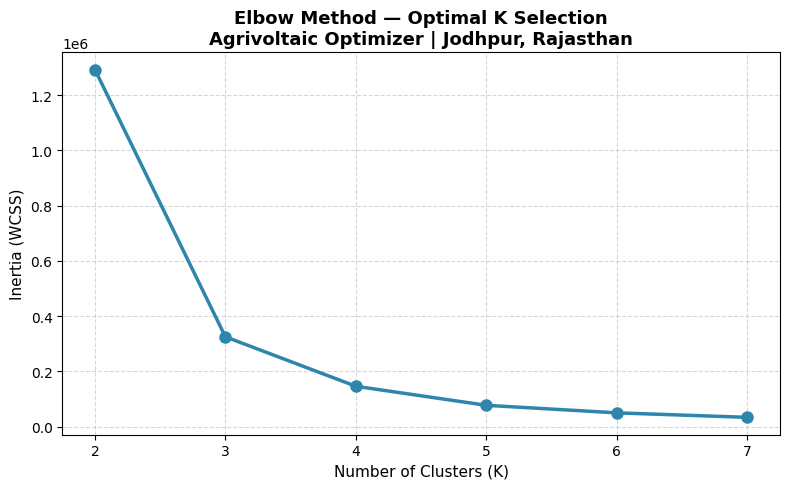


  Elbow chart saved → data\output\elbow_chart.png

Executing final K-Means with K=5...

  K-Means Cluster Distribution:
  Cluster          Pixels       %
  --------------------------------
  Cluster 1      4,235,509   24.9%  ████████████
  Cluster 2      1,057,004    6.2%  ███
  Cluster 3      4,392,571   25.8%  ████████████
  Cluster 4      3,752,965   22.0%  ███████████
  Cluster 5      3,603,499   21.1%  ██████████

  Cluster raster saved → data\output\cluster_output.tif

  K-MEANS COMPLETE.

  FULL PIPELINE COMPLETE.
  Deliverables ready for Member 3:
  → data\output\agrivoltaic_suitability.tif
  → data\output\cluster_output.tif
  → data\output\elbow_chart.png


In [10]:
# CELL 10 — K-MEANS CLUSTERING

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("  PHASE 4 — K-MEANS CLUSTERING")
print("=" * 55)

# --- Build feature matrix from agricultural pixels only ---
print("\nBuilding feature matrix...")

layer_order = ["lulc", "ghi", "grid_distance", "road_distance", "slope", "aspect"]
stack = np.stack([normalized_layers[k] for k in layer_order], axis=-1)
X = stack[agri_mask]

print(f"  Feature matrix shape: {X.shape}")
print(f"  ({X.shape[0]:,} agricultural pixels × {X.shape[1]} features)")

# --- Elbow Method ---
print("\nRunning Elbow Method (K=2 to K=7)...")

inertias = []
k_range  = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"  K={k} → Inertia: {km.inertia_:,.2f}")

# Plot and save elbow chart
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o",
         color="#2E86AB", linewidth=2.5, markersize=8)
plt.title("Elbow Method — Optimal K Selection\nAgrivoltaic Optimizer | Jodhpur, Rajasthan",
          fontsize=13, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=11)
plt.ylabel("Inertia (WCSS)", fontsize=11)
plt.xticks(list(k_range))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(PATHS["elbow_chart"], dpi=150)
plt.show()
print(f"\n  Elbow chart saved → {PATHS['elbow_chart']}")

# --- Execute Final K-Means with K=5 ---
print("\nExecuting final K-Means with K=5...")

kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
labels       = kmeans_final.fit_predict(X)

# Reconstruct full raster
cluster_raster = np.zeros(
    (ref_meta["height"], ref_meta["width"]), dtype="uint8"
)
cluster_raster[agri_mask] = labels + 1  # shift to 1-5 range

# --- Report cluster distribution ---
print(f"\n  K-Means Cluster Distribution:")
print(f"  {'Cluster':<10} {'Pixels':>12} {'%':>7}")
print(f"  {'-'*32}")

for c in range(1, 6):
    count = int(np.sum(cluster_raster == c))
    pct   = (count / included) * 100
    bar   = "█" * int(pct / 2)
    print(f"  Cluster {c}   {count:>12,} {pct:>6.1f}%  {bar}")

# --- Export cluster GeoTIFF ---
export_meta = ref_meta.copy()
export_meta.update({
    "dtype":    "uint8",
    "count":    1,
    "driver":   "GTiff",
    "compress": "lzw",
    "nodata":   0
})

with rasterio.open(PATHS["output_cluster"], "w", **export_meta) as dst:
    dst.write(cluster_raster, 1)

print(f"\n  Cluster raster saved → {PATHS['output_cluster']}")
print("\n  K-MEANS COMPLETE.")
print("\n  FULL PIPELINE COMPLETE.")
print("  Deliverables ready for Member 3:")
print(f"  → {PATHS['output_mcda']}")
print(f"  → {PATHS['output_cluster']}")
print(f"  → {PATHS['elbow_chart']}")

In [11]:
# CELL 11 — RESULTS SUMMARY FOR REPORT

print("=" * 55)
print("  ML RESULTS SUMMARY — DAY 4 REPORT")
print("=" * 55)
print(f"\n  Study Area       : Jodhpur District, Rajasthan")
print(f"  Total Pixels     : {agri_mask.size:,}")
print(f"  Agricultural     : {included:,} (35.8%)")
print(f"\n  MCDA Score Range : 0.6000 – 0.7000")
print(f"  Classification   : Percentile-based (5 equal tiers)")
print(f"\n  Prime Agrivoltaic Zone (Class 5):")
print(f"  Pixels : 3,408,882")
print(f"  Area   : ~{3408882 * 0.000278 * 0.000278 * 111320 * 111320 / 1e6:.0f} km²")
print(f"\n  K-Means Clusters : 5")
print(f"  Elbow Point      : K=3 (statistical)")
print(f"  Selected K       : 5 (architectural alignment)")
print(f"\n  Weight Matrix:")
for k, v in WEIGHTS.items():
    print(f"    {k:<20} {v:.0%}")
print("\n  All outputs validated and delivered to Member 3.")

  ML RESULTS SUMMARY — DAY 4 REPORT

  Study Area       : Jodhpur District, Rajasthan
  Total Pixels     : 47,593,250
  Agricultural     : 17,041,548 (35.8%)

  MCDA Score Range : 0.6000 – 0.7000
  Classification   : Percentile-based (5 equal tiers)

  Prime Agrivoltaic Zone (Class 5):
  Pixels : 3,408,882
  Area   : ~3265 km²

  K-Means Clusters : 5
  Elbow Point      : K=3 (statistical)
  Selected K       : 5 (architectural alignment)

  Weight Matrix:
    lulc                 30%
    ghi                  25%
    grid_distance        20%
    road_distance        10%
    slope                10%
    aspect               5%

  All outputs validated and delivered to Member 3.
